In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
# Plane stress FEM with 3-node triangular elements
# Unknowns: u_x, u_y at each node
# Element type: CST (constant strain triangle)

In [42]:
def read_model_data(csvfile):
    df = pd.read_csv(csvfile).fillna("")

    nodes_df = df[df["type"] == "NODE"].copy()
    elems_df = df[df["type"] == "ELEM"].copy()
    disp_df  = df[df["type"] == "DISP"].copy()
    force_df = df[df["type"] == "FORCE"].copy()
    trac_df  = df[df["type"] == "TRAC"].copy()
    mat_df   = df[df["type"] == "MAT"].copy()

    nodes = {}
    for _, row in nodes_df.iterrows():
        nid = int(row["id"])
        nodes[nid] = np.array([float(row["x"]), float(row["y"])], dtype=float)

    elements = []
    for _, row in elems_df.iterrows():
        eid = int(row["id"])
        conn = [int(row["n1"]), int(row["n2"]), int(row["n3"])]
        elements.append((eid, conn))

    disp_bcs = []
    for _, row in disp_df.iterrows():
        nid = int(row["id"])
        dof = str(row["dof"]).strip().lower()
        val = float(row["value"])
        disp_bcs.append((nid, dof, val))

    nodal_forces = []
    for _, row in force_df.iterrows():
        if row["id"] == "":
            continue
        nid = int(row["id"])
        dof = str(row["dof"]).strip().lower()
        val = float(row["value"])
        nodal_forces.append((nid, dof, val))

    trac_bcs = []
    for _, row in trac_df.iterrows():
        edge_nodes = [int(row["n2"]), int(row["n3"])]
        dof = str(row["dof"]).strip().lower()
        val = float(row["value"])
        trac_bcs.append((edge_nodes, dof, val))

    mat_row = mat_df.iloc[0]
    material = {
        "E": float(mat_row["E"]),
        "nu": float(mat_row["nu"]),
        "t": float(mat_row["thickness"]),
    }

    return nodes, elements, disp_bcs, nodal_forces, trac_bcs, material

In [43]:
def plane_stress_matrix(E, nu):
    return (E / (1.0 - nu**2)) * np.array([
        [1.0, nu, 0.0],
        [nu, 1.0, 0.0],
        [0.0, 0.0, 0.5 * (1.0 - nu)]
    ], dtype=float)

In [44]:
def triangle_area(xy):

    x1,y1 = xy[0]
    x2,y2 = xy[1]
    x3,y3 = xy[2]

    A = 0.5 * (
        x1*(y2-y3) +
        x2*(y3-y1) +
        x3*(y1-y2)
    )

    if abs(A) < 1e-12:
        raise ValueError(f"Degenerate triangle detected: area = {A}")

    return A

In [45]:
def triangle_B_matrix(xy):
    x1, y1 = xy[0]
    x2, y2 = xy[1]
    x3, y3 = xy[2]

    A = triangle_area(xy)

    b1 = y2 - y3
    b2 = y3 - y1
    b3 = y1 - y2

    c1 = x3 - x2
    c2 = x1 - x3
    c3 = x2 - x1

    B = (1.0 / (2.0 * A)) * np.array([
        [b1, 0.0, b2, 0.0, b3, 0.0],
        [0.0, c1, 0.0, c2, 0.0, c3],
        [c1, b1, c2, b2, c3, b3]
    ], dtype=float)

    return B

In [46]:
def triangle_stiffness(xy, E, nu, thickness):
    A = abs(triangle_area(xy))
    C = plane_stress_matrix(E, nu)
    B = triangle_B_matrix(xy)
    Ke = thickness * A * (B.T @ C @ B)
    return Ke, A, B, C

In [47]:
def node_dofs(nid):
    # zero-based indexing
    return [2*(nid-1), 2*(nid-1) + 1]

def element_dofs(conn):
    dofs = []
    for nid in conn:
        dofs.extend(node_dofs(nid))
    return dofs

In [48]:
def assemble_global_system(nodes, elements, material, nodal_forces, trac_bcs):
    nnodes = len(nodes)
    ndofs = 2 * nnodes

    K = np.zeros((ndofs, ndofs), dtype=float)
    F = np.zeros(ndofs, dtype=float)

    E = material["E"]
    nu = material["nu"]
    t = material["t"]

    elem_data = {}

    # --- element stiffness assembly ---
    for eid, conn in elements:
        xy = np.array([nodes[nid] for nid in conn], dtype=float)
        print(f"Checking element {eid}, conn = {conn}, xy = {xy}")
        Ke, A, B, C = triangle_stiffness(xy, E, nu, t)
        edofs = element_dofs(conn)

        for a in range(6):
            Aglob = edofs[a]
            for b in range(6):
                Bglob = edofs[b]
                K[Aglob, Bglob] += Ke[a, b]

        elem_data[eid] = {
            "conn": conn,
            "xy": xy,
            "Ke": Ke,
            "A": A,
            "B": B,
            "C": C
        }

    # --- nodal point loads ---
    for nid, dof, val in nodal_forces:
        if dof == "fx":
            F[2*(nid-1)] += val
        elif dof == "fy":
            F[2*(nid-1)+1] += val
        else:
            raise ValueError(f"Unknown force dof: {dof}")

    # --- edge traction loads ---
    for edge_nodes, dof, val in trac_bcs:
        eid, conn = find_element_for_edge(elements, edge_nodes)

        xy_edge = np.array([nodes[nid] for nid in edge_nodes], dtype=float)

        if dof == "tx":
            traction = np.array([val, 0.0], dtype=float)
        elif dof == "ty":
            traction = np.array([0.0, val], dtype=float)
        else:
            raise ValueError(f"Unknown traction dof: {dof}")

        fe_edge_4 = edge_traction_vector(xy_edge, traction, t)

        # Expand 4-vector to the 6-vector of the parent triangle
        fe_edge_6 = np.zeros(6, dtype=float)
        local_edge_dofs = edge_dofs_in_element(conn, edge_nodes)

        for i_local_edge, i_local_elem in enumerate(local_edge_dofs):
            fe_edge_6[i_local_elem] += fe_edge_4[i_local_edge]

        # Assemble into global F
        edofs = element_dofs(conn)
        for a in range(6):
            F[edofs[a]] += fe_edge_6[a]

    return K, F, elem_data

In [49]:
def apply_dirichlet_bc(K, F, disp_bcs):
    K_mod = K.copy()
    F_mod = F.copy()

    for nid, dof, val in disp_bcs:
        if dof == "ux":
            gdof = 2*(nid-1)
        elif dof == "uy":
            gdof = 2*(nid-1) + 1
        else:
            raise ValueError(f"Unknown displacement dof: {dof}")

        K_mod[gdof, :] = 0.0
        K_mod[:, gdof] = 0.0
        K_mod[gdof, gdof] = 1.0
        F_mod[gdof] = val

    return K_mod, F_mod

In [50]:
def edge_traction_vector(xy_edge, traction, thickness):
    """
    Consistent nodal load vector for a 2-node linear edge
    under constant traction.

    Parameters
    ----------
    xy_edge : (2,2) array
        Coordinates of the two edge nodes.
    traction : array-like length 2
        [tx, ty] traction components.
    thickness : float
        Plate thickness.

    Returns
    -------
    fe_edge : (4,) ndarray
        Edge load vector [Fx1, Fy1, Fx2, Fy2].
    """
    x1, y1 = xy_edge[0]
    x2, y2 = xy_edge[1]

    L = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    tx, ty = traction

    fe_edge = thickness * L / 2.0 * np.array([tx, ty, tx, ty], dtype=float)
    return fe_edge

In [51]:
def find_element_for_edge(elements, edge_nodes):
    """
    Find the first element containing the given edge.

    Parameters
    ----------
    elements : list of (eid, conn)
        conn is [n1, n2, n3]
    edge_nodes : list or tuple length 2
        [na, nb]

    Returns
    -------
    eid, conn : element id and connectivity
    """
    edge_set = set(edge_nodes)

    for eid, conn in elements:
        conn_set = set(conn)
        if edge_set.issubset(conn_set):
            return eid, conn

    raise ValueError(f"No element found containing edge {edge_nodes}")

In [52]:
def edge_dofs_in_element(conn, edge_nodes):
    """
    Return the local DOF indices in the 6x1 triangle vector corresponding
    to the two nodes on the edge.

    Example:
    conn = [5, 8, 9], edge_nodes = [8, 9]
    returns [2, 3, 4, 5] if 8 is local node 2 and 9 is local node 3.
    """
    local_dofs = []

    for nid in edge_nodes:
        local_index = conn.index(nid)   # 0, 1, or 2
        local_dofs.extend([2*local_index, 2*local_index + 1])

    return local_dofs

In [53]:
def solve_system(K, F):
    return np.linalg.solve(K, F)

In [54]:
def compute_element_strain_stress(elem_data, d_global):
    results = {}

    for eid, data in elem_data.items():
        conn = data["conn"]
        B = data["B"]
        C = data["C"]
        edofs = element_dofs(conn)

        d_e = d_global[edofs]
        strain = B @ d_e
        stress = C @ strain

        results[eid] = {
            "d_e": d_e,
            "strain": strain,
            "stress": stress
        }

    return results

In [55]:
csvfile = "plate_mesh.csv"

nodes, elements, disp_bcs, nodal_forces, trac_bcs, material = read_model_data(csvfile)

K, F, elem_data = assemble_global_system(nodes, elements, material, nodal_forces, trac_bcs)
K_mod, F_mod = apply_dirichlet_bc(K, F, disp_bcs)
d = solve_system(K_mod, F_mod)

elem_results = compute_element_strain_stress(elem_data, d)

Checking element 1, conn = [1, 2, 11], xy = [[0.5      0.      ]
 [0.535525 0.      ]
 [0.531348 0.069953]]
Checking element 2, conn = [1, 11, 10], xy = [[0.5      0.      ]
 [0.531348 0.069953]
 [0.495722 0.065263]]
Checking element 3, conn = [2, 3, 12], xy = [[0.535525 0.      ]
 [0.623704 0.      ]
 [0.619779 0.081595]]
Checking element 4, conn = [2, 12, 11], xy = [[0.535525 0.      ]
 [0.619779 0.081595]
 [0.531348 0.069953]]
Checking element 5, conn = [3, 4, 13], xy = [[0.623704 0.      ]
 [0.756654 0.      ]
 [0.753108 0.099149]]
Checking element 6, conn = [3, 13, 12], xy = [[0.623704 0.      ]
 [0.753108 0.099149]
 [0.619779 0.081595]]
Checking element 7, conn = [4, 5, 14], xy = [[0.756654 0.      ]
 [0.930762 0.      ]
 [0.927713 0.122136]]
Checking element 8, conn = [4, 14, 13], xy = [[0.756654 0.      ]
 [0.927713 0.122136]
 [0.753108 0.099149]]
Checking element 9, conn = [5, 6, 15], xy = [[0.930762 0.      ]
 [1.143688 0.      ]
 [1.141246 0.150248]]
Checking element 10, con

In [56]:
nnodes = len(nodes)
labels = []
for i in range(1, nnodes + 1):
    labels.append(f"u{i}x")
    labels.append(f"u{i}y")

F_df = pd.DataFrame(F, index=labels, columns=["Force"])
display(F_df)

,Force
u1x,0.000000
u1y,0.000000
u2x,0.000000
u2y,0.000000
u3x,0.000000
...,...
u115y,0.000000
u116x,0.000000
u116y,0.000000
u117x,0.000000


In [57]:
def plot_model(nodes, elements, disp_bcs, trac_bcs):
    
    plt.figure(figsize=(6,6))
    
    # ---- draw elements ----
    for eid, conn in elements:
        xy = np.array([nodes[n] for n in conn])
        xy_closed = np.vstack([xy, xy[0]])
        plt.plot(xy_closed[:,0], xy_closed[:,1], 'k-', linewidth=1)
        
        cx = np.mean(xy[:,0])
        cy = np.mean(xy[:,1])
        #plt.text(cx, cy, f"E{eid}", color="blue")

    # ---- draw nodes ----
    #for nid, xy in nodes.items():
        #plt.plot(xy[0], xy[1], 'ko')
        #plt.text(xy[0], xy[1], f"N{nid}", color="black")

    # ---- draw displacement BCs ----
    for nid, dof, val in disp_bcs:
        x,y = nodes[nid]

        if dof == "ux":
            plt.plot(x, y, 'ro', markersize=6)
        elif dof == "uy":
            plt.plot(x, y, 'go', markersize=6)

    # ---- draw traction edges ----
    for edge_nodes, dof, val in trac_bcs:

        n1, n2 = edge_nodes
        xy1 = nodes[n1]
        xy2 = nodes[n2]

        xs = [xy1[0], xy2[0]]
        ys = [xy1[1], xy2[1]]

        plt.plot(xs, ys, 'r-', linewidth=3)

        xm = (xy1[0]+xy2[0])/2
        ym = (xy1[1]+xy2[1])/2

        if dof == "ty":
            plt.arrow(xm, ym, 0, 0.2, width=0.01, color="red")
        if dof == "tx":
            plt.arrow(xm, ym, 0.2, 0, width=0.01, color="red")

    plt.gca().set_aspect('equal')
    #plt.xlabel("x")
    #plt.ylabel("y")
    plt.axis('off')
    #plt.title("Finite Element Model")
    plt.savefig("fe_mesh.png", dpi=300, bbox_inches='tight')
    plt.show()

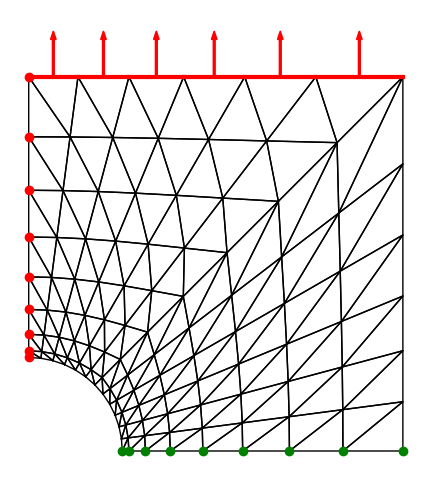

In [58]:
plot_model(nodes, elements, disp_bcs, trac_bcs)

In [59]:
for eid, res in elem_results.items():
    print(f"\nElement {eid}")
    print("strain =", res["strain"])
    print("stress =", res["stress"])


Element 1
strain = [-3.26494266e-12  1.35322307e-11  1.45939182e-12]
stress = [0.18339844 2.89678798 0.11787395]

Element 2
strain = [-3.65664644e-12  1.61397682e-11 -4.18378892e-12]
stress = [ 0.27352708  3.47140945 -0.33792141]

Element 3
strain = [-1.35769999e-12  9.64863095e-12  1.03565095e-12]
stress = [0.35466676 2.13261253 0.08364873]

Element 4
strain = [-1.84989589e-12  1.33199303e-11 -2.01154913e-12]
stress = [ 0.49524997  2.94576034 -0.16247128]

Element 5
strain = [-6.01596178e-13  7.36409380e-12  8.02600001e-13]
stress = [0.37099199 1.6577573  0.06482538]

Element 6
strain = [-8.00688804e-13  9.56742343e-12 -6.25740191e-13]
stress = [ 0.47758574  2.15243464 -0.05054055]

Element 7
strain = [-5.68133288e-13  6.20426477e-12  6.54892901e-13]
stress = [0.29841834 1.3924211  0.0528952 ]

Element 8
strain = [-6.71803260e-13  7.33521419e-12 -7.40796200e-15]
stress = [ 3.52790999e-01  1.64623228e+00 -5.98335392e-04]

Element 9
strain = [-7.80960621e-13  5.54731441e-12  5.56666866

In [60]:
def plot_mesh(nodes, elements, d=None, scale=1.0):
    plt.figure(figsize=(6, 5))

    for eid, conn in elements:
        xy = np.array([nodes[nid] for nid in conn], dtype=float)
        xy_closed = np.vstack([xy, xy[0]])
        plt.plot(xy_closed[:, 0], xy_closed[:, 1], 'k-')

        cx = np.mean(xy[:, 0])
        cy = np.mean(xy[:, 1])
        #plt.text(cx, cy, f"{eid}", color="blue")

    for nid, xy in nodes.items():
        plt.plot(xy[0], xy[1], 'ko')
        plt.text(xy[0], xy[1], f" {nid}", color="red")

    if d is not None:
        def_nodes = {}
        for nid, xy in nodes.items():
            ux = d[2*(nid-1)]
            uy = d[2*(nid-1)+1]
            def_nodes[nid] = xy + scale*np.array([ux, uy])

        for eid, conn in elements:
            xy = np.array([def_nodes[nid] for nid in conn], dtype=float)
            xy_closed = np.vstack([xy, xy[0]])
            plt.plot(xy_closed[:, 0], xy_closed[:, 1], '--')

    plt.axis('equal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Mesh')
    plt.show()

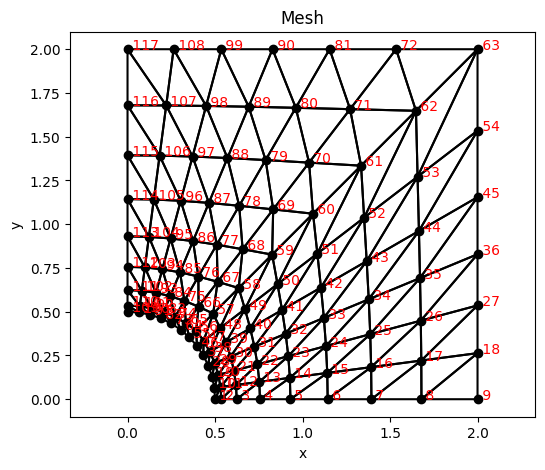

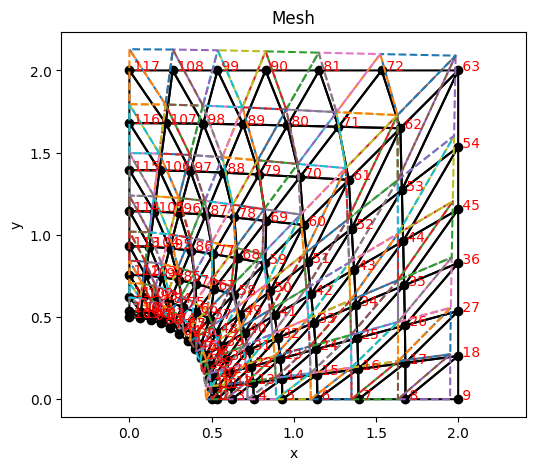

In [61]:
plot_mesh(nodes, elements)
plot_mesh(nodes, elements, d=d, scale=1e10)


In [62]:
nnodes = len(nodes)

labels = []
for i in range(1, nnodes+1):
    labels.append(f"u{i}x")
    labels.append(f"u{i}y")

K_df = pd.DataFrame(K, index=labels, columns=labels)

display(K_df)

,u1x,u1y,u2x,u2y,u3x,u3y,u4x,u4y,u5x,u5y,...,u113x,u113y,u114x,u114y,u115x,u115y,u116x,u116y,u117x,u117y
u1x,2.504287e+09,3.474819e+07,-2.250783e+09,2.579695e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
u1y,3.474819e+07,1.431587e+09,3.156618e+08,-7.344247e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
u2x,-2.250783e+09,3.156618e+08,4.031939e+09,-7.522778e+08,-1.049131e+09,3.127700e+08,0.000000e+00,0.000000e+00,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
u2y,2.579695e+08,-7.344247e+08,-7.522778e+08,3.083696e+09,3.704624e+08,-3.206591e+08,0.000000e+00,0.000000e+00,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
u3x,0.000000e+00,0.000000e+00,-1.049131e+09,3.704624e+08,3.015239e+09,-8.569488e+08,-8.464360e+08,3.261501e+08,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
u115y,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,...,0.0,0.0,-3.534789e+08,-6.999914e+08,6.269301e+08,2.649956e+09,-4.083834e+08,-7.436931e+08,0.000000e+00,0.000000e+00
u116x,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,-2.699030e+08,-4.083834e+08,3.725072e+09,6.286853e+08,-2.832663e+08,-3.482928e+08
u116y,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,-3.506911e+08,-7.436931e+08,6.286853e+08,2.673941e+09,-4.059851e+08,-7.973338e+08
u117x,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,...,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.832663e+08,-4.059851e+08,1.695435e+09,-1.183828e+08


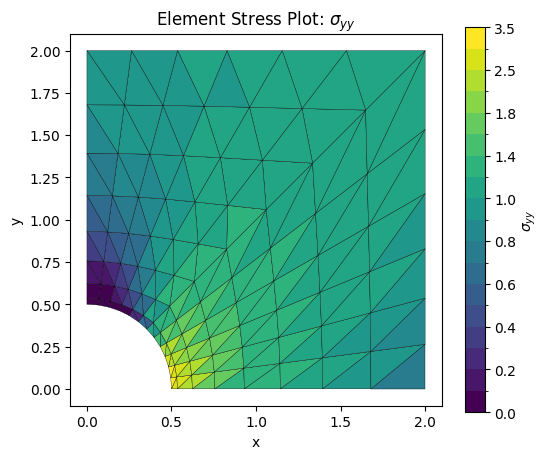

In [63]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.colors as mcolors
import numpy as np

node_ids = sorted(nodes.keys())

x = np.array([nodes[i][0] for i in node_ids])
y = np.array([nodes[i][1] for i in node_ids])

triangles = np.array([[n-1 for n in conn] for _, conn in elements])

sigma_yy = np.array([elem_results[eid]["stress"][1] for eid,_ in elements])

triang = tri.Triangulation(x, y, triangles)

bounds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5,
          0.6, 0.7, 0.8, 0.9, 1.0,
          1.2, 1.4, 1.6, 1.8, 2.0,
          2.5, 3.0, 3.5]

norm = mcolors.BoundaryNorm(bounds, ncolors=256, clip=False)

plt.figure(figsize=(6,5))

tpc = plt.tripcolor(
    triang,
    facecolors=sigma_yy,
    edgecolors='k',
    cmap='viridis',
    norm=norm
)

plt.colorbar(tpc, label=r'$\sigma_{yy}$')
plt.gca().set_aspect('equal')
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Element Stress Plot: $\sigma_{yy}$")
plt.savefig("fe_contour.png", dpi=300, bbox_inches='tight')
plt.show()
